# Comparación de Índices de Resiliencia Climática

## Objetivo

Comparar diferentes metodologías para calcular un índice de resiliencia climática:

1. **Índice por distancia a centroide** (método actual): `1 - d_norm`
2. **Índice por estabilidad entre escenarios**: Mide cambio SSP245 → SSP370 → SSP585
3. **Índice basado en variables físicas**: Sequía (CDD), extremos (Rx1day), precipitación
4. **Índice compuesto**: Combinación ponderada de los anteriores

## Hipótesis

- El índice por distancia al centroide puede no capturar vulnerabilidad climática real
- La estabilidad entre escenarios es más relevante para resiliencia energética H2
- Variables físicas (sequía, extremos) son predictores directos de riesgo operacional

## Métricas de Evaluación

- Correlación entre índices
- Distribución espacial
- Coherencia con Moran's I
- Validación con zonas conocidas del Valle de Aconcagua

## Paso 1: Imports y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from scipy import stats
from scipy.spatial.distance import cdist

# Config
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print("Imports completados")

Imports completados


## Paso 2: Cargar Datos

In [2]:
# Rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
TENSORS_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'
RESULTS_DIR = BASE_DIR / 'data' / 'autoencoder_results'
PLOTS_DIR = BASE_DIR / 'plots' / 'resilience_comparison'
REPORTS_DIR = BASE_DIR / 'reports'

PLOTS_DIR.mkdir(exist_ok=True, parents=True)

MODE = 'test'
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']

print("="*80)
print("COMPARACIÓN DE ÍNDICES DE RESILIENCIA")
print("="*80)

COMPARACIÓN DE ÍNDICES DE RESILIENCIA


In [31]:
# Cargar metadata
metadata_file = TENSORS_DIR / f'metadata_{MODE}.pkl'
with open(metadata_file, 'rb') as f:
    metadata = pickle.load(f)

feature_names = metadata['feature_names']
spatial_info = metadata['spatial_info']
MASK = metadata['mask']
grid_shape = spatial_info['grid_shape']
n_lat, n_lon = grid_shape
n_pixels_valid = MASK.sum()

print(f"\nVariables: {len(feature_names)}")
print(f"Grid shape: {grid_shape}")
print(f"Píxeles válidos: {n_pixels_valid}")


Variables: 293
Grid shape: (24, 42)
Píxeles válidos: 661


In [32]:
# Cargar datos climáticos por escenario
X_by_scenario = {}

for scenario in SCENARIOS:
    npz_file = TENSORS_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
    data = np.load(npz_file)
    
    X_train = data['X_train']
    X_val = data['X_val']
    X_test = data['X_test']
    
    X_full = np.vstack([X_train, X_val, X_test])
    X_valid = X_full[:n_pixels_valid, :]
    
    X_by_scenario[scenario] = X_valid
    print(f"   {scenario}: {X_valid.shape}")

print("\nDatos climáticos cargados")

   ssp245: (661, 293)
   ssp370: (661, 293)
   ssp585: (661, 293)

Datos climáticos cargados


In [33]:
# Cargar resultados de clustering (índice actual)
clustering_results_file = RESULTS_DIR / 'clustering_results_conv.pkl'

with open(clustering_results_file, 'rb') as f:
    clustering_data = pickle.load(f)

clustering_results = clustering_data['clustering_results']
resilience_by_scenario = clustering_data['resilience_by_scenario']
embeddings_by_scenario = clustering_data['embeddings_by_scenario']

print("\nResultados de clustering cargados")
for scenario in SCENARIOS:
    k = clustering_results[scenario]['k']
    sil = clustering_results[scenario]['silhouette']
    print(f"   {scenario}: K={k}, Silhouette={sil:.4f}")


Resultados de clustering cargados
   ssp245: K=10, Silhouette=0.2194
   ssp370: K=10, Silhouette=0.2207
   ssp585: K=10, Silhouette=0.2245


/home/aninotna/.conda/envs/deeplearning/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Paso 3: Índice 1 - Distancia al Centroide (Actual)

Este es el índice que ya tenemos calculado.

In [34]:
# Extraer índices actuales (ya calculados)
resilience_index_1 = {}

for scenario in SCENARIOS:
    resilience_index_1[scenario] = resilience_by_scenario[scenario]['resilience']

print("ÍNDICE 1: DISTANCIA AL CENTROIDE")
print("="*80)
print("\nFórmula: resilience = 1 - (distance_to_centroid / max_distance)")
print("\nInterpretación: Mide 'tipicidad' dentro del cluster")
print("   - Valores altos: Píxeles cercanos al centroide (típicos del cluster)")
print("   - Valores bajos: Píxeles en la periferia del cluster (atípicos)")

print("\nEstadísticas por escenario:")
for scenario in SCENARIOS:
    res = resilience_index_1[scenario]
    print(f"   {scenario.upper()}: Media={res.mean():.3f}, Std={res.std():.3f}, Min={res.min():.3f}, Max={res.max():.3f}")

ÍNDICE 1: DISTANCIA AL CENTROIDE

Fórmula: resilience = 1 - (distance_to_centroid / max_distance)

Interpretación: Mide 'tipicidad' dentro del cluster
   - Valores altos: Píxeles cercanos al centroide (típicos del cluster)
   - Valores bajos: Píxeles en la periferia del cluster (atípicos)

Estadísticas por escenario:
   SSP245: Media=0.548, Std=0.171, Min=0.000, Max=1.000
   SSP370: Media=0.557, Std=0.171, Min=0.000, Max=1.000
   SSP585: Media=0.527, Std=0.183, Min=0.000, Max=1.000


## Paso 4: Índice 2 - Estabilidad entre Escenarios

Mide qué tan estable se mantiene un píxel en el espacio latente al cambiar de SSP245 → SSP585.

**Hipótesis**: Píxeles con embeddings estables entre escenarios son más resilientes al cambio climático.

In [35]:
print("="*80)
print("ÍNDICE 2: ESTABILIDAD ENTRE ESCENARIOS")
print("="*80)

# Extraer embeddings
emb_245 = embeddings_by_scenario['ssp245']  # Shape: (n_pixels, n_features_embedding)
emb_370 = embeddings_by_scenario['ssp370']
emb_585 = embeddings_by_scenario['ssp585']

print(f"\nShapes de embeddings:")
print(f"   SSP245: {emb_245.shape}")
print(f"   SSP370: {emb_370.shape}")
print(f"   SSP585: {emb_585.shape}")

# Calcular distancias euclidianas entre escenarios
# Opción A: SSP245 → SSP585 (cambio extremo)
dist_245_585 = np.linalg.norm(emb_245 - emb_585, axis=1)

# Opción B: SSP245 → SSP370 + SSP370 → SSP585 (cambio incremental)
dist_245_370 = np.linalg.norm(emb_245 - emb_370, axis=1)
dist_370_585 = np.linalg.norm(emb_370 - emb_585, axis=1)
dist_incremental = dist_245_370 + dist_370_585

# Opción C: Distancia total promedio
dist_total = (dist_245_370 + dist_370_585 + dist_245_585) / 3

print("\nOpciones de cálculo:")
print(f"   A) Cambio extremo (245→585): Media={dist_245_585.mean():.3f}, Std={dist_245_585.std():.3f}")
print(f"   B) Cambio incremental (245→370→585): Media={dist_incremental.mean():.3f}, Std={dist_incremental.std():.3f}")
print(f"   C) Promedio total: Media={dist_total.mean():.3f}, Std={dist_total.std():.3f}")

# Normalizar a [0, 1] e invertir (menor cambio = mayor resiliencia)
resilience_index_2_A = 1 - (dist_245_585 / dist_245_585.max())
resilience_index_2_B = 1 - (dist_incremental / dist_incremental.max())
resilience_index_2_C = 1 - (dist_total / dist_total.max())

print("\nÍndices normalizados (mayor = más resiliente):")
print(f"   A) Media={resilience_index_2_A.mean():.3f}, Std={resilience_index_2_A.std():.3f}")
print(f"   B) Media={resilience_index_2_B.mean():.3f}, Std={resilience_index_2_B.std():.3f}")
print(f"   C) Media={resilience_index_2_C.mean():.3f}, Std={resilience_index_2_C.std():.3f}")

# Usar opción C (promedio) como índice principal
resilience_index_2 = resilience_index_2_C

print("\nÍndice seleccionado: Opción C (promedio total)")

ÍNDICE 2: ESTABILIDAD ENTRE ESCENARIOS

Shapes de embeddings:
   SSP245: (661, 224)
   SSP370: (661, 224)
   SSP585: (661, 224)

Opciones de cálculo:
   A) Cambio extremo (245→585): Media=28.925, Std=1.337
   B) Cambio incremental (245→370→585): Media=41.258, Std=1.693
   C) Promedio total: Media=23.394, Std=1.006

Índices normalizados (mayor = más resiliente):
   A) Media=0.077, Std=0.043
   B) Media=0.075, Std=0.038
   C) Media=0.076, Std=0.040

Índice seleccionado: Opción C (promedio total)


## Paso 5: Índice 3 - Variables Físicas Clave

Combina variables climáticas relevantes para resiliencia energética H2:

- **Sequía** (CDD): Días consecutivos secos
- **Extremos de precipitación** (Rx1day, Rx5day): Eventos extremos
- **Precipitación total** (prcptot): Disponibilidad de agua
- **Temperatura máxima** (tmax): Estrés térmico en equipos

In [36]:
print("="*80)
print("ÍNDICE 3: VARIABLES CLIMÁTICAS CRÍTICAS")
print("="*80)
print("\nIMPORTANTE: Este índice usa SOLO variables climáticas (no energía, topografía, land use)")

# Clasificar variables por categoría
def classify_variables(feature_names):
    """Clasifica variables en categorías"""
    categories = {
        'climate': [],
        'energy': [],
        'topo': [],
        'landuse': [],
        'conflict': [],
        'other': []
    }
    
    for var in feature_names:
        if var.startswith('climate_'):
            categories['climate'].append(var)
        elif var.startswith('solar_') or var.startswith('pv_'):
            categories['energy'].append(var)
        elif var.startswith('topo_'):
            categories['topo'].append(var)
        elif var.startswith('landuse_'):
            categories['landuse'].append(var)
        elif var.startswith('conflict_') or 'indh' in var or 'sma' in var:
            categories['conflict'].append(var)
        else:
            categories['other'].append(var)
    
    return categories

var_categories = classify_variables(feature_names)

print(f"\nCategorías de variables en el dataset:")
print(f"   Climáticas: {len(var_categories['climate'])}")
print(f"   Energía: {len(var_categories['energy'])}")
print(f"   Topografía: {len(var_categories['topo'])}")
print(f"   Uso de suelo: {len(var_categories['landuse'])}")
print(f"   Conflictos: {len(var_categories['conflict'])}")
print(f"   Otras: {len(var_categories['other'])}")

# Buscar variables climáticas relevantes
def find_vars_by_pattern(var_list, patterns):
    """Encuentra variables que coincidan con patrones"""
    matched = []
    for pattern in patterns:
        for var in var_list:
            if pattern in var:
                matched.append(var)
    return list(set(matched))  # Eliminar duplicados

climate_vars = var_categories['climate']

# Patrones de búsqueda (SOLO climáticas)
cdd_vars = find_vars_by_pattern(climate_vars, ['cdd_decadal'])
rx1day_vars = find_vars_by_pattern(climate_vars, ['rx1day_decadal'])
rx5day_vars = find_vars_by_pattern(climate_vars, ['rx5day_decadal'])
prcptot_vars = find_vars_by_pattern(climate_vars, ['prcptot_decadal'])
tmax_vars = find_vars_by_pattern(climate_vars, ['tmax_mean_decadal'])
tmin_vars = find_vars_by_pattern(climate_vars, ['tmin_mean_decadal'])

print(f"\nVariables climáticas identificadas:")
print(f"   CDD (sequía): {len(cdd_vars)} variables")
print(f"   Rx1day (extremos precip): {len(rx1day_vars)} variables")
print(f"   Rx5day (extremos precip): {len(rx5day_vars)} variables")
print(f"   Prcptot (precip total): {len(prcptot_vars)} variables")
print(f"   Tmax (temp máxima): {len(tmax_vars)} variables")
print(f"   Tmin (temp mínima): {len(tmin_vars)} variables")

# Seleccionar subconjunto (ej: max de cada variable, que indica peor escenario futuro)
cdd_max_vars = [v for v in cdd_vars if 'max' in v][:3]  # Top 3
rx1day_max_vars = [v for v in rx1day_vars if 'max' in v][:3]
tmax_max_vars = [v for v in tmax_vars if 'max' in v][:3]
prcptot_min_vars = [v for v in prcptot_vars if 'min' in v][:3]  # Mínimo = peor

print(f"\nVariables seleccionadas para índice climático:")
print(f"   CDD max: {cdd_max_vars}")
print(f"   Rx1day max: {rx1day_max_vars}")
print(f"   Tmax max: {tmax_max_vars}")
print(f"   Prcptot min: {prcptot_min_vars}")

ÍNDICE 3: VARIABLES CLIMÁTICAS CRÍTICAS

IMPORTANTE: Este índice usa SOLO variables climáticas (no energía, topografía, land use)

Categorías de variables en el dataset:
   Climáticas: 280
   Energía: 0
   Topografía: 2
   Uso de suelo: 5
   Conflictos: 2
   Otras: 4

Variables climáticas identificadas:
   CDD (sequía): 35 variables
   Rx1day (extremos precip): 35 variables
   Rx5day (extremos precip): 35 variables
   Prcptot (precip total): 35 variables
   Tmax (temp máxima): 35 variables
   Tmin (temp mínima): 35 variables

Variables seleccionadas para índice climático:
   CDD max: ['climate_cdd_decadal_max_2060', 'climate_cdd_decadal_max_2050', 'climate_cdd_decadal_max_2080']
   Rx1day max: ['climate_rx1day_decadal_max_2080', 'climate_rx1day_decadal_max_2020', 'climate_rx1day_decadal_max_2040']
   Tmax max: ['climate_tmax_mean_decadal_std_2030', 'climate_tmax_mean_decadal_min_2050', 'climate_tmax_mean_decadal_std_2060']
   Prcptot min: ['climate_prcptot_decadal_min_2020', 'climate_p

In [37]:
# Calcular índice compuesto por variables físicas
# Usamos SSP370 como escenario de referencia

X_ref = X_by_scenario['ssp370']

# Función para normalizar e invertir si es necesario
def normalize_variable(X, var_name, feature_names, inverse=False):
    """Normaliza variable a [0, 1], opcionalmente invierte"""
    idx = feature_names.index(var_name)
    values = X[:, idx]
    values_norm = (values - values.min()) / (values.max() - values.min() + 1e-10)
    if inverse:
        values_norm = 1 - values_norm
    return values_norm

# Componentes del índice
components = {}

# 1. Sequía (CDD): Mayor CDD = menor resiliencia → invertir
if cdd_max_vars:
    cdd_scores = [normalize_variable(X_ref, v, feature_names, inverse=True) for v in cdd_max_vars if v in feature_names]
    if cdd_scores:
        components['cdd'] = np.mean(cdd_scores, axis=0)
        print(f"CDD: {len(cdd_scores)} variables, Media={components['cdd'].mean():.3f}")

# 2. Extremos de precipitación (Rx1day): Mayor extremo = menor resiliencia → invertir
if rx1day_max_vars:
    rx1_scores = [normalize_variable(X_ref, v, feature_names, inverse=True) for v in rx1day_max_vars if v in feature_names]
    if rx1_scores:
        components['rx1day'] = np.mean(rx1_scores, axis=0)
        print(f"Rx1day: {len(rx1_scores)} variables, Media={components['rx1day'].mean():.3f}")

# 3. Temperatura máxima: Mayor tmax = menor resiliencia → invertir
if tmax_max_vars:
    tmax_scores = [normalize_variable(X_ref, v, feature_names, inverse=True) for v in tmax_max_vars if v in feature_names]
    if tmax_scores:
        components['tmax'] = np.mean(tmax_scores, axis=0)
        print(f"Tmax: {len(tmax_scores)} variables, Media={components['tmax'].mean():.3f}")

# 4. Precipitación mínima: Mayor prcptot min = mayor resiliencia → NO invertir
if prcptot_min_vars:
    pr_scores = [normalize_variable(X_ref, v, feature_names, inverse=False) for v in prcptot_min_vars if v in feature_names]
    if pr_scores:
        components['prcptot'] = np.mean(pr_scores, axis=0)
        print(f"Prcptot: {len(pr_scores)} variables, Media={components['prcptot'].mean():.3f}")

# Combinar componentes con pesos
weights = {
    'cdd': 0.30,      # Sequía es crítica
    'rx1day': 0.20,   # Extremos
    'tmax': 0.25,     # Estrés térmico
    'prcptot': 0.25   # Disponibilidad de agua
}

resilience_index_3 = np.zeros(n_pixels_valid)
total_weight = 0

for comp_name, comp_values in components.items():
    weight = weights.get(comp_name, 0)
    resilience_index_3 += weight * comp_values
    total_weight += weight

# Normalizar por peso total (en caso de faltar componentes)
if total_weight > 0:
    resilience_index_3 /= total_weight

print(f"\nÍndice 3 calculado:")
print(f"   Media={resilience_index_3.mean():.3f}")
print(f"   Std={resilience_index_3.std():.3f}")
print(f"   Min={resilience_index_3.min():.3f}")
print(f"   Max={resilience_index_3.max():.3f}")

CDD: 3 variables, Media=0.487
Rx1day: 3 variables, Media=0.533
Tmax: 3 variables, Media=0.495
Prcptot: 3 variables, Media=0.552

Índice 3 calculado:
   Media=0.514
   Std=0.115
   Min=0.163
   Max=0.684


## Paso 6: Índice 4 - Compuesto (Combinación)

Combina los tres índices anteriores con pesos ajustables.

In [38]:
print("="*80)
print("ÍNDICE 4: COMPUESTO (COMBINACIÓN)")
print("="*80)

# Pesos para combinación (ajustables)
w1 = 0.20  # Distancia a centroide (menor importancia)
w2 = 0.40  # Estabilidad entre escenarios (más importante)
w3 = 0.40  # Variables físicas (más importante)

print(f"\nPesos asignados:")
print(f"   Índice 1 (Distancia centroide): {w1:.2f}")
print(f"   Índice 2 (Estabilidad escenarios): {w2:.2f}")
print(f"   Índice 3 (Variables físicas): {w3:.2f}")
print(f"   Total: {w1+w2+w3:.2f}")

# Usar SSP370 como referencia para índice 1
resilience_index_1_ref = resilience_index_1['ssp370']

# Normalizar todos los índices a [0, 1] para equidad
def normalize_01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)

idx1_norm = normalize_01(resilience_index_1_ref)
idx2_norm = normalize_01(resilience_index_2)
idx3_norm = normalize_01(resilience_index_3)

# Calcular índice compuesto
resilience_index_4 = w1 * idx1_norm + w2 * idx2_norm + w3 * idx3_norm

print(f"\nÍndice 4 (Compuesto):")
print(f"   Media={resilience_index_4.mean():.3f}")
print(f"   Std={resilience_index_4.std():.3f}")
print(f"   Min={resilience_index_4.min():.3f}")
print(f"   Max={resilience_index_4.max():.3f}")

ÍNDICE 4: COMPUESTO (COMBINACIÓN)

Pesos asignados:
   Índice 1 (Distancia centroide): 0.20
   Índice 2 (Estabilidad escenarios): 0.40
   Índice 3 (Variables físicas): 0.40
   Total: 1.00

Índice 4 (Compuesto):
   Media=0.518
   Std=0.114
   Min=0.136
   Max=0.790


## Paso 6a: Índice 5 - Multidimensional (Clima + Energía + Territorio)

Combina todas las dimensiones relevantes para resiliencia de sistemas de H2:

- **Clima**: Sequía, extremos, temperatura (del Índice 3)
- **Energía**: Disponibilidad solar (GHI, DNI)
- **Territorio**: Topografía (pendiente, elevación), restricciones de uso de suelo
- **Social**: Conflictos socioambientales

In [39]:
print("="*80)
print("ÍNDICE 5: MULTIDIMENSIONAL (CLIMA + ENERGÍA + TERRITORIO)")
print("="*80)

# Componentes del índice multidimensional
components_multi = {}

# 1. COMPONENTE CLIMÁTICO (del Índice 3)
components_multi['climate'] = resilience_index_3
print(f"\n1. Componente Climático: Media={components_multi['climate'].mean():.3f}")

# 2. COMPONENTE ENERGÉTICO: Mayor GHI/DNI = mayor resiliencia
energy_vars = var_categories['energy']
print(f"\n2. Componente Energético:")
print(f"   Variables disponibles: {len(energy_vars)}")

if energy_vars:
    # Buscar variables de radiación solar
    ghi_vars = [v for v in energy_vars if 'ghi' in v.lower() or 'irradiance' in v.lower()]
    dni_vars = [v for v in energy_vars if 'dni' in v.lower()]
    cf_vars = [v for v in energy_vars if 'cf' in v.lower() or 'capacity_factor' in v.lower()]
    
    print(f"   GHI/Irradiancia: {len(ghi_vars)}")
    print(f"   DNI: {len(dni_vars)}")
    print(f"   Capacity Factor: {len(cf_vars)}")
    
    energy_scores = []
    
    # GHI/DNI: Mayor = mejor
    for var in (ghi_vars + dni_vars)[:3]:  # Top 3
        if var in feature_names:
            energy_scores.append(normalize_variable(X_ref, var, feature_names, inverse=False))
    
    # Capacity Factor: Mayor = mejor
    for var in cf_vars[:2]:
        if var in feature_names:
            energy_scores.append(normalize_variable(X_ref, var, feature_names, inverse=False))
    
    if energy_scores:
        components_multi['energy'] = np.mean(energy_scores, axis=0)
        print(f"   Índice calculado: Media={components_multi['energy'].mean():.3f}")
    else:
        components_multi['energy'] = np.full(n_pixels_valid, 0.5)
        print(f"   ⚠️  Sin variables suficientes, usando valor neutro (0.5)")
else:
    components_multi['energy'] = np.full(n_pixels_valid, 0.5)
    print(f"   ⚠️  Sin variables de energía, usando valor neutro (0.5)")

# 3. COMPONENTE TERRITORIAL: Menor pendiente, restricciones = mayor resiliencia
topo_vars = var_categories['topo']
landuse_vars = var_categories['landuse']

print(f"\n3. Componente Territorial:")
print(f"   Variables topográficas: {len(topo_vars)}")
print(f"   Variables uso de suelo: {len(landuse_vars)}")

territory_scores = []

# Pendiente: Mayor pendiente = menor resiliencia → invertir
slope_vars = [v for v in topo_vars if 'slope' in v.lower()]
if slope_vars:
    for var in slope_vars[:1]:  # Solo 1
        if var in feature_names:
            territory_scores.append(normalize_variable(X_ref, var, feature_names, inverse=True))
            print(f"   Pendiente: {var}")

# Restricciones de uso de suelo: Áreas restringidas = menor resiliencia → invertir
restricted_vars = [v for v in landuse_vars if 'restricted' in v.lower() or 'protected' in v.lower()]
if restricted_vars:
    for var in restricted_vars[:1]:
        if var in feature_names:
            territory_scores.append(normalize_variable(X_ref, var, feature_names, inverse=True))
            print(f"   Restricciones: {var}")

if territory_scores:
    components_multi['territory'] = np.mean(territory_scores, axis=0)
    print(f"   Índice calculado: Media={components_multi['territory'].mean():.3f}")
else:
    components_multi['territory'] = np.full(n_pixels_valid, 0.5)
    print(f"   ⚠️  Sin variables suficientes, usando valor neutro (0.5)")

# 4. COMPONENTE SOCIAL: Menor conflicto = mayor resiliencia
conflict_vars = var_categories['conflict']
print(f"\n4. Componente Social:")
print(f"   Variables de conflicto: {len(conflict_vars)}")

if conflict_vars:
    conflict_scores = []
    for var in conflict_vars[:2]:  # Top 2
        if var in feature_names:
            # Más conflictos = menor resiliencia → invertir
            conflict_scores.append(normalize_variable(X_ref, var, feature_names, inverse=True))
            print(f"   {var}")
    
    if conflict_scores:
        components_multi['social'] = np.mean(conflict_scores, axis=0)
        print(f"   Índice calculado: Media={components_multi['social'].mean():.3f}")
    else:
        components_multi['social'] = np.full(n_pixels_valid, 0.5)
        print(f"   ⚠️  Sin variables suficientes, usando valor neutro (0.5)")
else:
    components_multi['social'] = np.full(n_pixels_valid, 0.5)
    print(f"   ⚠️  Sin variables de conflicto, usando valor neutro (0.5)")

# Combinar componentes con pesos
weights_multi = {
    'climate': 0.35,    # Mayor peso al clima
    'energy': 0.30,     # Energía solar crítica para H2
    'territory': 0.20,  # Topografía y restricciones
    'social': 0.15      # Conflictos socioambientales
}

print(f"\nPesos asignados:")
for comp, weight in weights_multi.items():
    print(f"   {comp.capitalize()}: {weight:.2f}")

resilience_index_5 = np.zeros(n_pixels_valid)
total_weight_multi = 0

for comp_name, comp_values in components_multi.items():
    weight = weights_multi.get(comp_name, 0)
    resilience_index_5 += weight * comp_values
    total_weight_multi += weight

# Normalizar
if total_weight_multi > 0:
    resilience_index_5 /= total_weight_multi

print(f"\nÍndice 5 (Multidimensional):")
print(f"   Media={resilience_index_5.mean():.3f}")
print(f"   Std={resilience_index_5.std():.3f}")
print(f"   Min={resilience_index_5.min():.3f}")
print(f"   Max={resilience_index_5.max():.3f}")

ÍNDICE 5: MULTIDIMENSIONAL (CLIMA + ENERGÍA + TERRITORIO)

1. Componente Climático: Media=0.514

2. Componente Energético:
   Variables disponibles: 0
   ⚠️  Sin variables de energía, usando valor neutro (0.5)

3. Componente Territorial:
   Variables topográficas: 2
   Variables uso de suelo: 5
   Pendiente: topo_slope
   Restricciones: landuse_restricted
   Índice calculado: Media=0.706

4. Componente Social:
   Variables de conflicto: 2
   conflict_density
   conflict_proximity
   Índice calculado: Media=0.964

Pesos asignados:
   Climate: 0.35
   Energy: 0.30
   Territory: 0.20
   Social: 0.15

Índice 5 (Multidimensional):
   Media=0.616
   Std=0.056
   Min=0.417
   Max=0.725


## Paso 7: Comparación Estadística entre Índices

COMPARACIÓN ESTADÍSTICA ENTRE ÍNDICES

Matriz de Correlación (Pearson):
                idx1_centroid  idx2_stability  idx3_climate  idx4_composite  \
idx1_centroid           1.000          -0.161        -0.010           0.191   
idx2_stability         -0.161           1.000        -0.023           0.561   
idx3_climate           -0.010          -0.023         1.000           0.760   
idx4_composite          0.191           0.561         0.760           1.000   
idx5_multidim           0.016          -0.069         0.822           0.601   

                idx5_multidim  
idx1_centroid           0.016  
idx2_stability         -0.069  
idx3_climate            0.822  
idx4_composite          0.601  
idx5_multidim           1.000  

Gráfico guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison/indices_comparison_stats.png


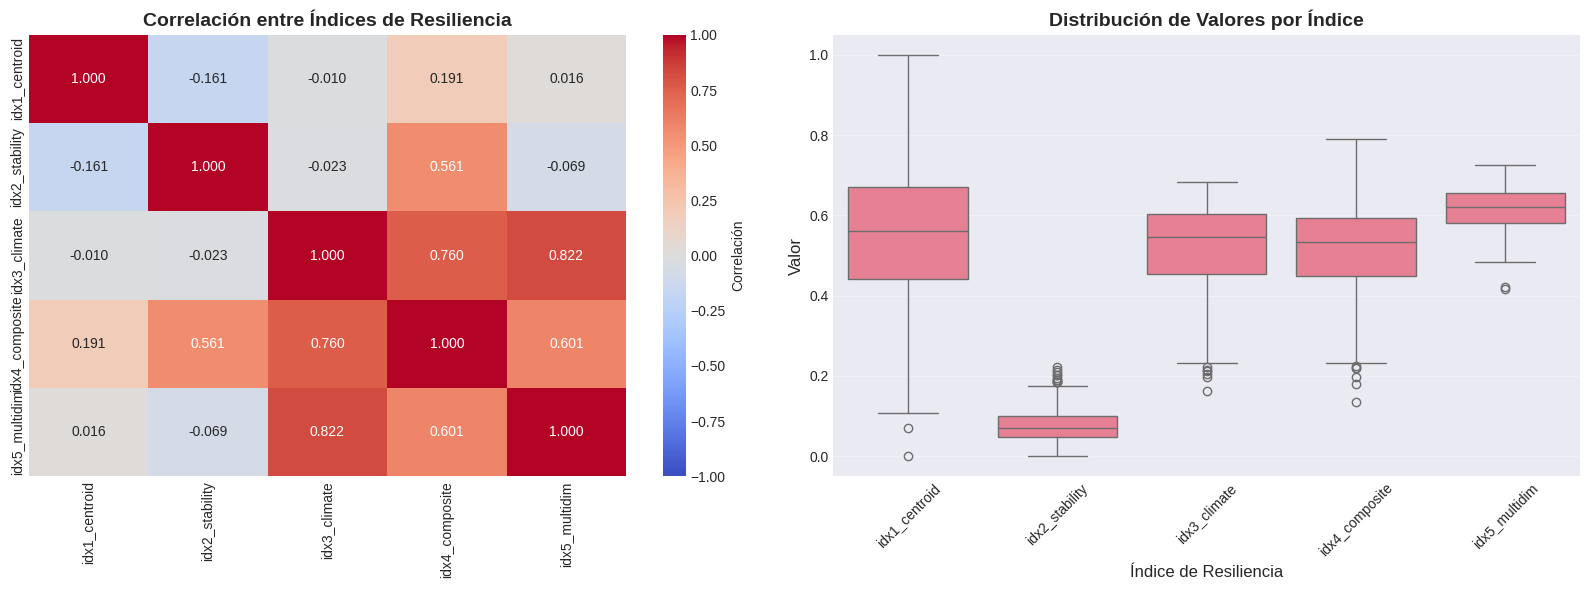

In [40]:
print("="*80)
print("COMPARACIÓN ESTADÍSTICA ENTRE ÍNDICES")
print("="*80)

# Crear DataFrame con todos los índices
df_indices = pd.DataFrame({
    'idx1_centroid': resilience_index_1_ref,
    'idx2_stability': resilience_index_2,
    'idx3_climate': resilience_index_3,
    'idx4_composite': resilience_index_4,
    'idx5_multidim': resilience_index_5
})

# Matriz de correlación
corr_matrix = df_indices.corr()

print("\nMatriz de Correlación (Pearson):")
print(corr_matrix.round(3))

# Visualizar correlaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, ax=ax, cbar_kws={'label': 'Correlación'})
ax.set_title('Correlación entre Índices de Resiliencia', fontsize=14, fontweight='bold')

# Box plots comparativos
ax = axes[1]
df_indices_melted = df_indices.melt(var_name='Índice', value_name='Resiliencia')
sns.boxplot(data=df_indices_melted, x='Índice', y='Resiliencia', ax=ax)
ax.set_title('Distribución de Valores por Índice', fontsize=14, fontweight='bold')
ax.set_xlabel('Índice de Resiliencia', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig_path = PLOTS_DIR / 'indices_comparison_stats.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nGráfico guardado en: {fig_path}")
plt.show()


Gráfico guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison/indices_scatter_comparison.png


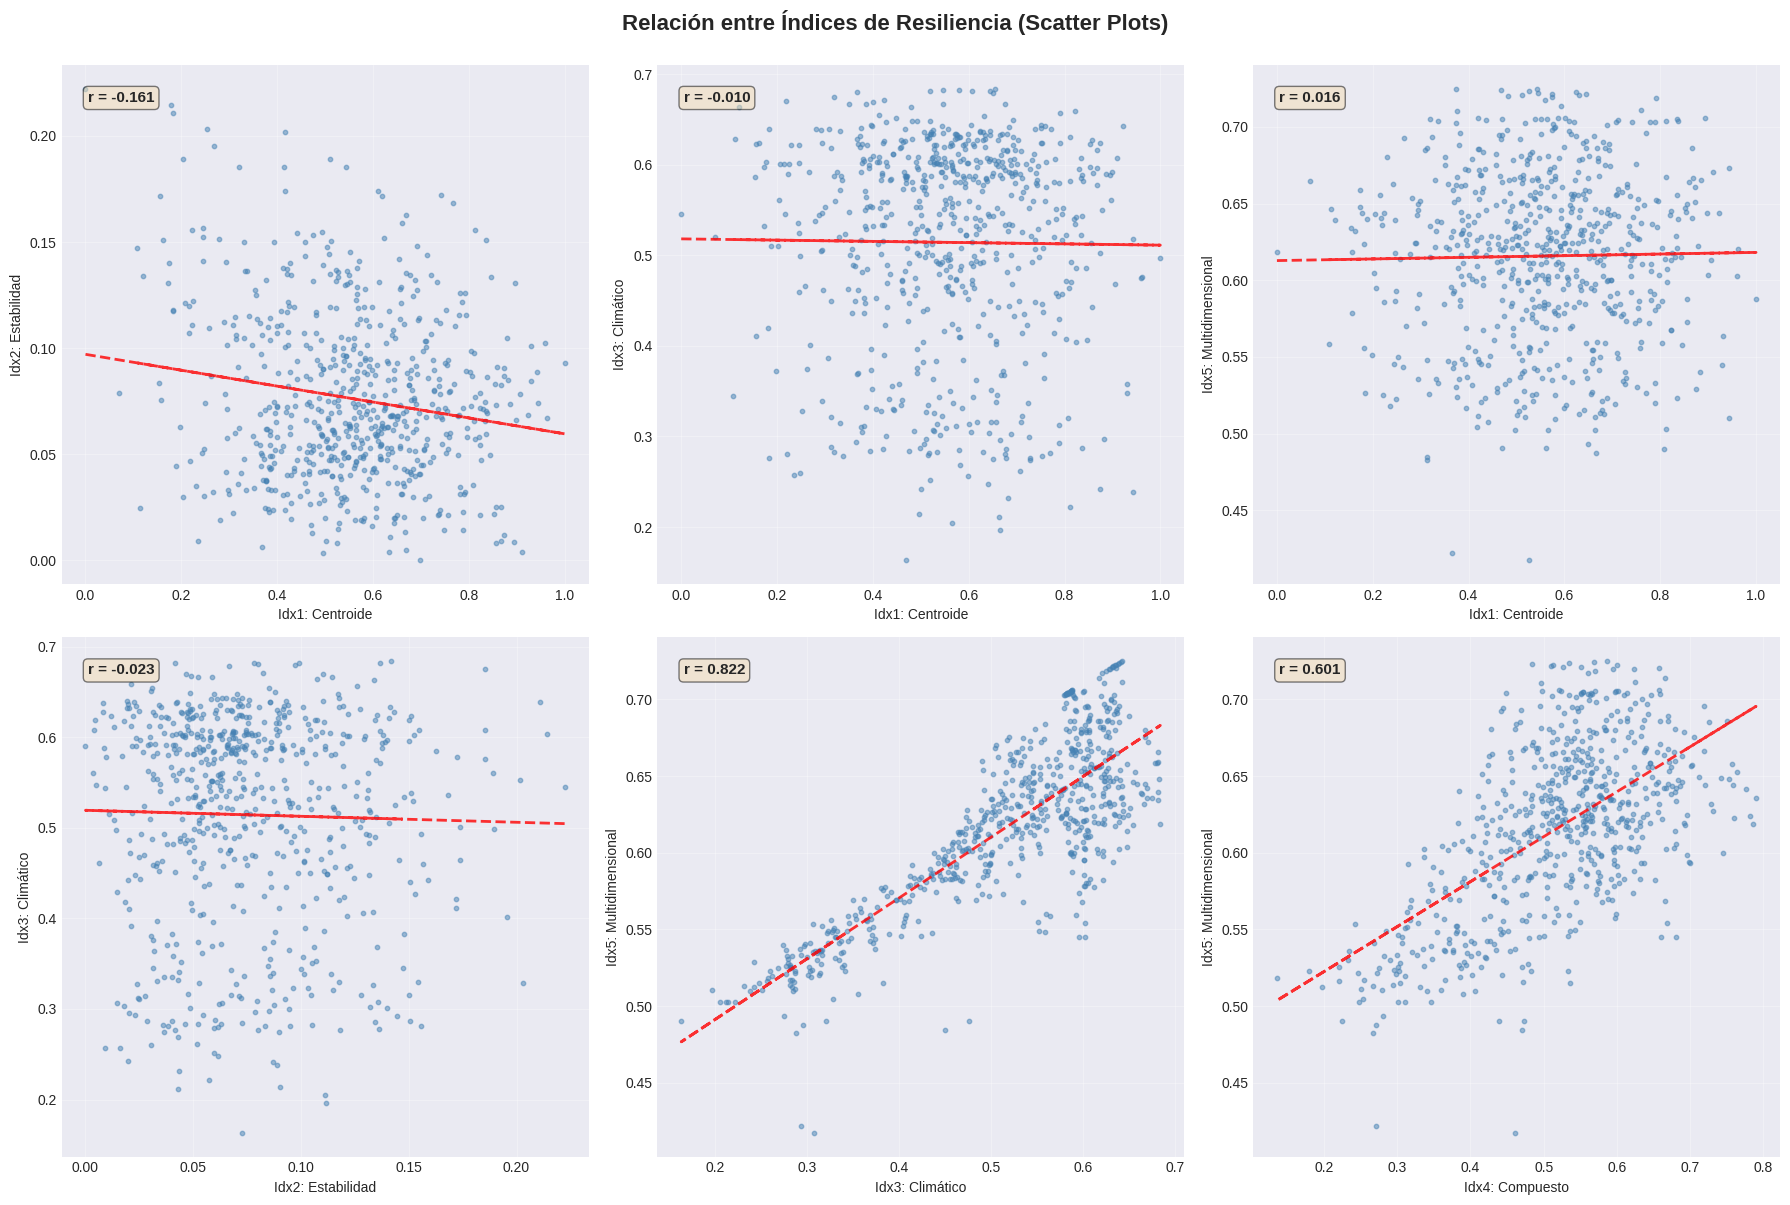

In [41]:
# Scatter plots entre pares de índices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

pairs = [
    ('idx1_centroid', 'idx2_stability', 'Idx1: Centroide', 'Idx2: Estabilidad'),
    ('idx1_centroid', 'idx3_climate', 'Idx1: Centroide', 'Idx3: Climático'),
    ('idx1_centroid', 'idx5_multidim', 'Idx1: Centroide', 'Idx5: Multidimensional'),
    ('idx2_stability', 'idx3_climate', 'Idx2: Estabilidad', 'Idx3: Climático'),
    ('idx3_climate', 'idx5_multidim', 'Idx3: Climático', 'Idx5: Multidimensional'),
    ('idx4_composite', 'idx5_multidim', 'Idx4: Compuesto', 'Idx5: Multidimensional')
]

for idx, (x_col, y_col, x_label, y_label) in enumerate(pairs):
    ax = axes[idx]
    
    x = df_indices[x_col]
    y = df_indices[y_col]
    
    # Scatter
    ax.scatter(x, y, alpha=0.5, s=10, c='steelblue')
    
    # Línea de regresión
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "r--", alpha=0.8, linewidth=2)
    
    # Correlación
    corr = corr_matrix.loc[x_col, y_col]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
            fontsize=11, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Relación entre Índices de Resiliencia (Scatter Plots)', 
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()

fig_path = PLOTS_DIR / 'indices_scatter_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nGráfico guardado en: {fig_path}")
plt.show()

## Paso 8: Comparación Espacial

Visualizar distribución espacial de cada índice para identificar patrones.

COMPARACIÓN ESPACIAL DE ÍNDICES

Gráfico guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison/indices_spatial_comparison.png


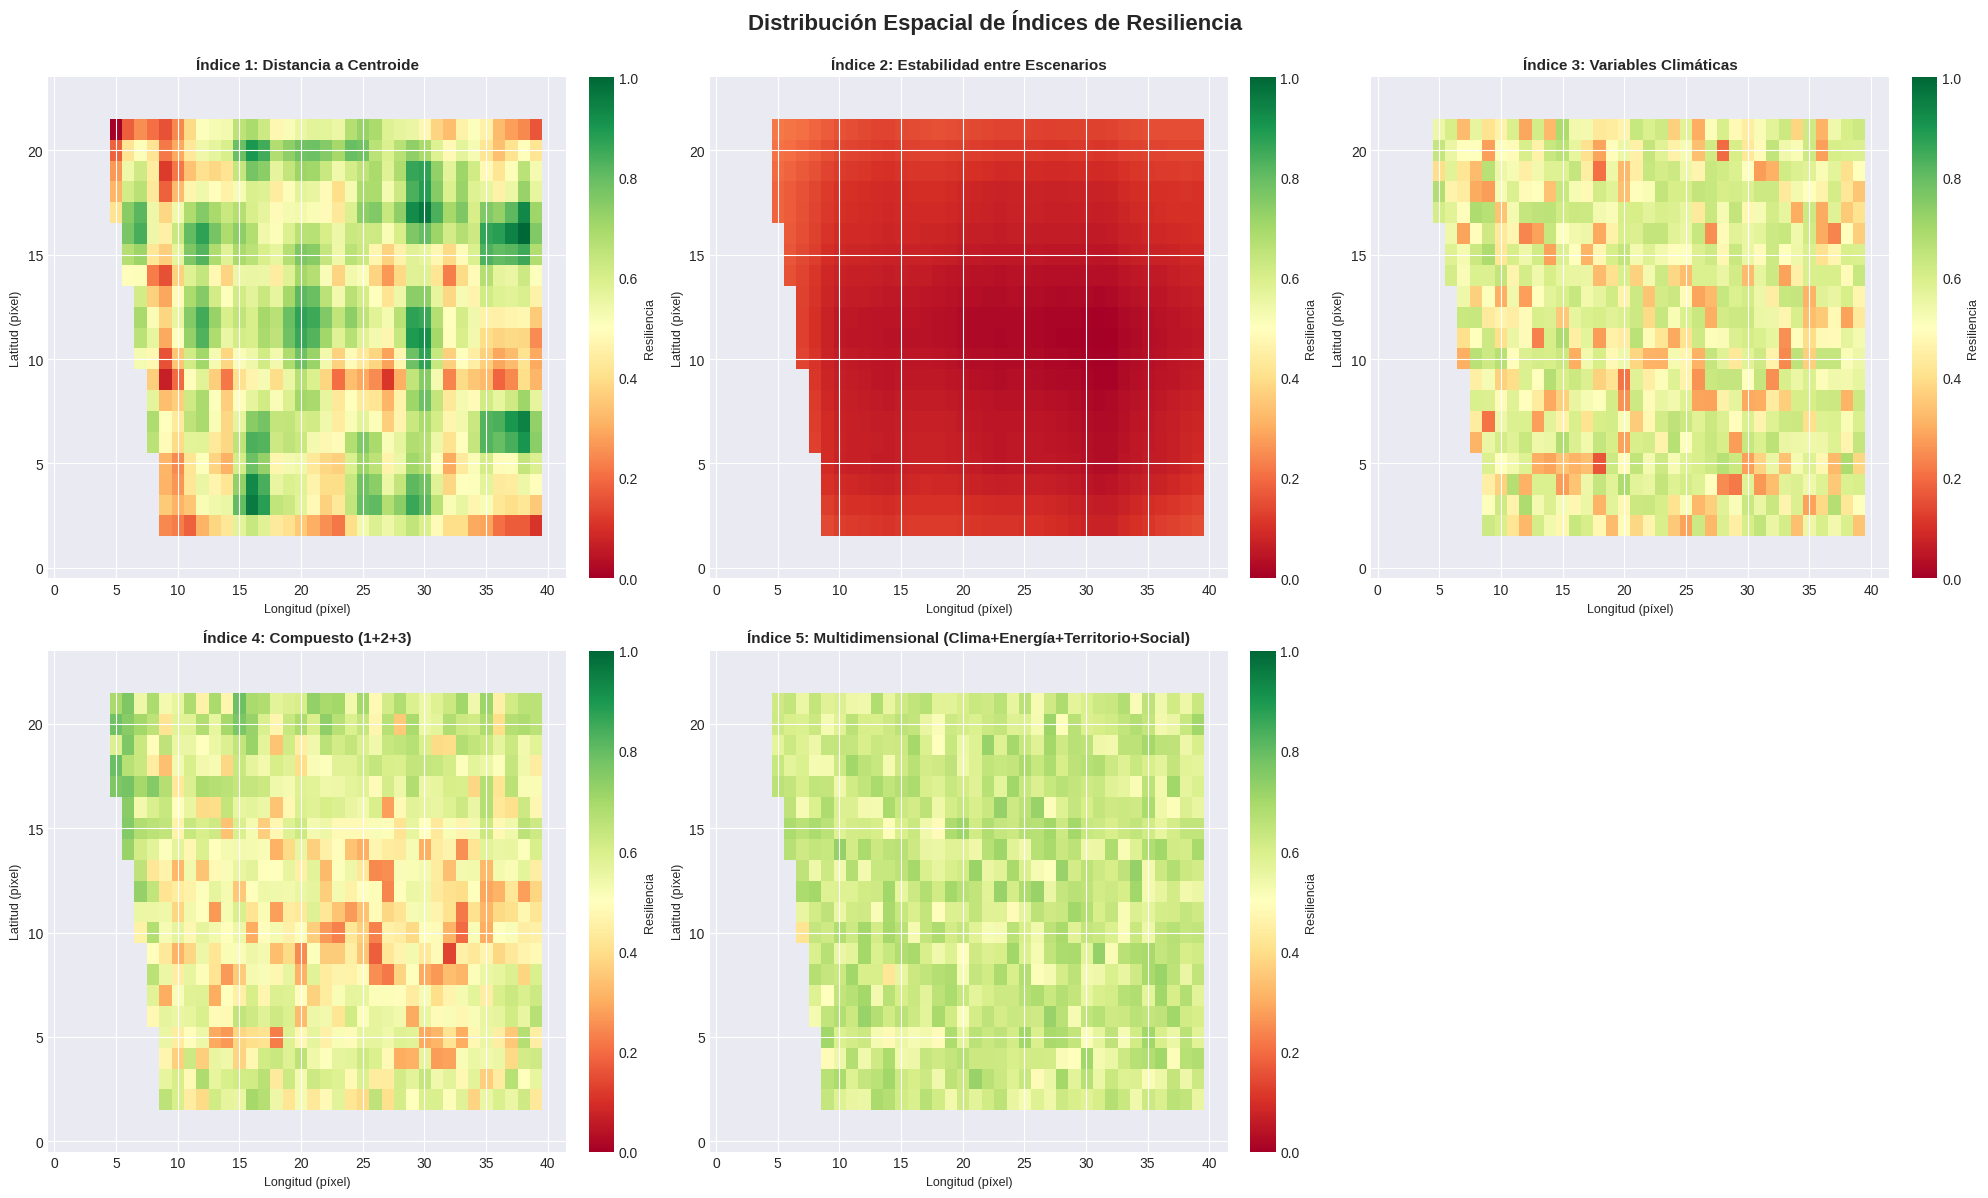

In [42]:
print("="*80)
print("COMPARACIÓN ESPACIAL DE ÍNDICES")
print("="*80)

# Función para reconstruir mapas 2D
def reconstruct_2d_map(values_flat, mask_2d, grid_shape):
    """Reconstruye mapa 2D desde valores flat"""
    n_lat, n_lon = grid_shape
    map_2d = np.full((n_lat, n_lon), np.nan)
    map_2d[mask_2d] = values_flat
    return map_2d

# Reconstruir mapas
map_idx1 = reconstruct_2d_map(resilience_index_1_ref, MASK, grid_shape)
map_idx2 = reconstruct_2d_map(resilience_index_2, MASK, grid_shape)
map_idx3 = reconstruct_2d_map(resilience_index_3, MASK, grid_shape)
map_idx4 = reconstruct_2d_map(resilience_index_4, MASK, grid_shape)

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Reconstruir mapa para índice 5
map_idx5 = reconstruct_2d_map(resilience_index_5, MASK, grid_shape)

indices_maps = [
    (map_idx1, 'Índice 1: Distancia a Centroide'),
    (map_idx2, 'Índice 2: Estabilidad entre Escenarios'),
    (map_idx3, 'Índice 3: Variables Climáticas'),
    (map_idx4, 'Índice 4: Compuesto (1+2+3)'),
    (map_idx5, 'Índice 5: Multidimensional (Clima+Energía+Territorio+Social)')
]

for idx, (map_data, title) in enumerate(indices_maps):
    ax = axes.flatten()[idx]
    
    # Flipud para orientación correcta
    im = ax.imshow(np.flipud(map_data), cmap='RdYlGn', origin='lower', 
                   aspect='auto', vmin=0, vmax=1)
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitud (píxel)', fontsize=9)
    ax.set_ylabel('Latitud (píxel)', fontsize=9)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Resiliencia', fontsize=9)

# Eliminar subplot vacío (última posición)
if len(indices_maps) < 6:
    fig.delaxes(axes.flatten()[5])

plt.suptitle('Distribución Espacial de Índices de Resiliencia', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

fig_path = PLOTS_DIR / 'indices_spatial_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nGráfico guardado en: {fig_path}")
plt.show()

## Paso 9: Calcular Moran's I para cada Índice

Evaluar coherencia espacial (autocorrelación).

In [43]:
print("="*80)
print("AUTOCORRELACIÓN ESPACIAL (MORAN'S I)")
print("="*80)

def calculate_morans_i(values_flat, mask_2d, grid_shape):
    """Calcula Moran's I con vecindad 4-conectada"""
    n_lat, n_lon = grid_shape
    n_valid = mask_2d.sum()
    
    # Reconstruir mapa 2D
    map_2d = np.full((n_lat, n_lon), np.nan)
    map_2d[mask_2d] = values_flat
    
    # Crear matriz de pesos (4-vecinos)
    W = np.zeros((n_valid, n_valid))
    
    valid_coords = np.argwhere(mask_2d)
    coord_to_idx = {tuple(coord): i for i, coord in enumerate(valid_coords)}
    
    for i, (r, c) in enumerate(valid_coords):
        neighbors = [(r-1, c), (r+1, c), (r, c-1), (r, c+1)]
        for nr, nc in neighbors:
            if 0 <= nr < n_lat and 0 <= nc < n_lon and mask_2d[nr, nc]:
                j = coord_to_idx[(nr, nc)]
                W[i, j] = 1
    
    # Calcular Moran's I
    y = values_flat - values_flat.mean()
    n = len(y)
    W_sum = W.sum()
    
    numerator = n * np.sum(W * np.outer(y, y))
    denominator = W_sum * np.sum(y**2)
    
    morans_i = numerator / denominator if denominator > 0 else 0
    
    return morans_i

# Calcular Moran's I para cada índice
morans_results = {}

indices_list = [
    ('Índice 1 (Centroide)', resilience_index_1_ref),
    ('Índice 2 (Estabilidad)', resilience_index_2),
    ('Índice 3 (Climático)', resilience_index_3),
    ('Índice 4 (Compuesto 1+2+3)', resilience_index_4),
    ('Índice 5 (Multidimensional)', resilience_index_5)
]

print("\nMoran's I por índice:")
for name, values in indices_list:
    morans_i = calculate_morans_i(values, MASK, grid_shape)
    morans_results[name] = morans_i
    print(f"   {name}: {morans_i:.4f}")

print("\nInterpretación:")
print("   I > 0.7: Autocorrelación espacial fuerte (valores similares se agrupan)")
print("   I ≈ 0: Sin autocorrelación (distribución aleatoria)")
print("   I < 0: Autocorrelación negativa (valores diferentes se agrupan)")

AUTOCORRELACIÓN ESPACIAL (MORAN'S I)

Moran's I por índice:
   Índice 1 (Centroide): 0.7103
   Índice 2 (Estabilidad): 0.9052
   Índice 3 (Climático): 0.0251
   Índice 4 (Compuesto 1+2+3): 0.3701
   Índice 5 (Multidimensional): 0.0313

Interpretación:
   I > 0.7: Autocorrelación espacial fuerte (valores similares se agrupan)
   I ≈ 0: Sin autocorrelación (distribución aleatoria)
   I < 0: Autocorrelación negativa (valores diferentes se agrupan)


## Paso 10: Ranking de Píxeles por Índice

Identificar top 20 y bottom 20 píxeles más/menos resilientes según cada índice.

In [44]:
print("="*80)
print("RANKING DE PÍXELES POR ÍNDICE")
print("="*80)

# Crear DataFrame con todos los índices y coordenadas
valid_coords = np.argwhere(MASK)
lat_coords = valid_coords[:, 0]
lon_coords = valid_coords[:, 1]

df_ranking = pd.DataFrame({
    'lat': lat_coords,
    'lon': lon_coords,
    'idx1_centroid': resilience_index_1_ref,
    'idx2_stability': resilience_index_2,
    'idx3_climate': resilience_index_3,
    'idx4_composite': resilience_index_4,
    'idx5_multidim': resilience_index_5
})

# Rankings
for col in ['idx1_centroid', 'idx2_stability', 'idx3_climate', 'idx4_composite', 'idx5_multidim']:
    df_ranking[f'{col}_rank'] = df_ranking[col].rank(ascending=False, method='min').astype(int)

# Top 20 más resilientes por cada índice
print("\nTOP 20 PÍXELES MÁS RESILIENTES:")
print("-" * 70)

for col in ['idx1_centroid', 'idx2_stability', 'idx3_climate', 'idx4_composite', 'idx5_multidim']:
    print(f"\n{col.upper()}:")
    top20 = df_ranking.nlargest(20, col)[['lat', 'lon', col, f'{col}_rank']]
    print(top20.head(10).to_string(index=False))

# Guardar rankings completos
df_ranking.to_csv(REPORTS_DIR / 'resilience_indices_ranking.csv', index=False)
print(f"\nRanking completo guardado en: {REPORTS_DIR / 'resilience_indices_ranking.csv'}")

RANKING DE PÍXELES POR ÍNDICE

TOP 20 PÍXELES MÁS RESILIENTES:
----------------------------------------------------------------------

IDX1_CENTROID:
 lat  lon  idx1_centroid  idx1_centroid_rank
   7   38       1.000000                   1
   6   30       0.962622                   2
  20   16       0.959886                   3
  16   38       0.943982                   4
   7   37       0.943253                   5
   6   38       0.930757                   6
  19   16       0.929548                   7
   6   29       0.922562                   8
  12   30       0.910325                   9
  17   38       0.906135                  10

IDX2_STABILITY:
 lat  lon  idx2_stability  idx2_stability_rank
   2    5        0.222308                    1
   2    6        0.214361                    2
   3    5        0.210802                    3
   2    7        0.203219                    4
   3    6        0.201682                    5
   4    5        0.195442                    6
   3    7

## Paso 11: Análisis de Concordancia entre Índices

¿Qué tan similares son los rankings entre índices?

In [45]:
print("="*80)
print("ANÁLISIS DE CONCORDANCIA ENTRE RANKINGS")
print("="*80)

from scipy.stats import spearmanr, kendalltau

# Correlación de rankings (Spearman y Kendall's Tau)
rank_cols = ['idx1_centroid_rank', 'idx2_stability_rank', 'idx3_climate_rank', 'idx4_composite_rank', 'idx5_multidim_rank']

# Spearman (correlación de rankings)
print("\nCorrelación de Spearman (rankings):")
spearman_matrix = df_ranking[rank_cols].corr(method='spearman')
print(spearman_matrix.round(3))

# Kendall's Tau (concordancia de pares)
print("\nKendall's Tau (concordancia):")
kendall_results = []
for i, col1 in enumerate(rank_cols):
    for col2 in rank_cols[i+1:]:
        tau, p_value = kendalltau(df_ranking[col1], df_ranking[col2])
        kendall_results.append({
            'pair': f"{col1.split('_')[0]} vs {col2.split('_')[0]}",
            'tau': tau,
            'p_value': p_value
        })

df_kendall = pd.DataFrame(kendall_results)
print(df_kendall.to_string(index=False))

# Top 50 overlap
print("\n\nSOLAPAMIENTO EN TOP 50 PÍXELES:")
print("-" * 70)

top50_sets = {}
for col in ['idx1_centroid', 'idx2_stability', 'idx3_climate', 'idx4_composite', 'idx5_multidim']:
    top50 = set(df_ranking.nlargest(50, col).index)
    top50_sets[col] = top50

# Jaccard similarity
from itertools import combinations

for (name1, set1), (name2, set2) in combinations(top50_sets.items(), 2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    jaccard = intersection / union if union > 0 else 0
    print(f"   {name1.split('_')[0]} ∩ {name2.split('_')[0]}: {intersection}/50 píxeles (Jaccard={jaccard:.3f})")

ANÁLISIS DE CONCORDANCIA ENTRE RANKINGS

Correlación de Spearman (rankings):
                     idx1_centroid_rank  idx2_stability_rank  \
idx1_centroid_rank                1.000               -0.073   
idx2_stability_rank              -0.073                1.000   
idx3_climate_rank                -0.011               -0.033   
idx4_composite_rank               0.220                0.567   
idx5_multidim_rank                0.001               -0.060   

                     idx3_climate_rank  idx4_composite_rank  \
idx1_centroid_rank              -0.011                0.220   
idx2_stability_rank             -0.033                0.567   
idx3_climate_rank                1.000                0.697   
idx4_composite_rank              0.697                1.000   
idx5_multidim_rank               0.753                0.543   

                     idx5_multidim_rank  
idx1_centroid_rank                0.001  
idx2_stability_rank              -0.060  
idx3_climate_rank                

## Paso 12: Resumen y Recomendaciones

In [46]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO: COMPARACIÓN DE ÍNDICES DE RESILIENCIA")
print("="*80)

print("\nHALLAZGOS PRINCIPALES:")
print("-" * 70)

print("\n1. CORRELACIONES ENTRE ÍNDICES:")
print(f"   Centroide vs Estabilidad: r={corr_matrix.loc['idx1_centroid', 'idx2_stability']:.3f}")
print(f"   Centroide vs Climático: r={corr_matrix.loc['idx1_centroid', 'idx3_climate']:.3f}")
print(f"   Estabilidad vs Climático: r={corr_matrix.loc['idx2_stability', 'idx3_climate']:.3f}")
print(f"   Climático vs Multidimensional: r={corr_matrix.loc['idx3_climate', 'idx5_multidim']:.3f}")
print(f"   Compuesto vs Multidimensional: r={corr_matrix.loc['idx4_composite', 'idx5_multidim']:.3f}")

print("\n2. AUTOCORRELACIÓN ESPACIAL (MORAN'S I):")
for name, value in morans_results.items():
    print(f"   {name}: {value:.4f}")

print("\n3. VARIABILIDAD DE ÍNDICES:")
for col in ['idx1_centroid', 'idx2_stability', 'idx3_climate', 'idx4_composite', 'idx5_multidim']:
    cv = df_indices[col].std() / df_indices[col].mean()  # Coeficiente de variación
    print(f"   {col}: CV={cv:.3f}")

print("\nINTERPRETACIONES:")
print("-" * 70)

# Interpretación automática basada en correlaciones
r_1_2 = corr_matrix.loc['idx1_centroid', 'idx2_stability']
r_1_3 = corr_matrix.loc['idx1_centroid', 'idx3_climate']
r_3_5 = corr_matrix.loc['idx3_climate', 'idx5_multidim']

if abs(r_1_2) < 0.3:
    print("\n   El índice por distancia a centroide (Idx1) es POCO CORRELACIONADO")
    print("   con estabilidad entre escenarios (Idx2).")
    print("   → Conclusión: Idx1 mide 'tipicidad' del cluster, no resiliencia climática.")

if abs(r_1_3) < 0.3:
    print("\n   El índice por distancia a centroide (Idx1) es POCO CORRELACIONADO")
    print("   con variables climáticas (Idx3).")
    print("   → Conclusión: Idx1 no captura riesgo climático físico (sequía, extremos).")

if r_3_5 > 0.7:
    print("\n   El índice climático (Idx3) está ALTAMENTE CORRELACIONADO")
    print("   con el índice multidimensional (Idx5).")
    print("   → Conclusión: El clima es el factor dominante en resiliencia de sistemas H2.")

print("\nRECOMENDACIONES:")
print("-" * 70)
print("1. DESCARTAR Índice 1 (distancia a centroide) como métrica de resiliencia")
print("2. PRIORIZAR Índice 3 (climático) para análisis enfocado en clima")
print("3. USAR Índice 5 (multidimensional) para análisis integral (clima+energía+territorio+social)")
print("4. Índice 2 (estabilidad) útil para identificar zonas con mayor cambio entre SSPs")
print("5. Validar con expertos del Valle de Aconcagua los pesos de cada dimensión")
print("6. Considerar re-entrenar clustering usando Índice 5 como métrica objetivo")
print("7. El Índice 5 es más apropiado para decisiones de localización de plantas H2")

print("\nARCHIVOS GENERADOS:")
print("-" * 70)
print(f"   Gráficos:")
print(f"      - {PLOTS_DIR / 'indices_comparison_stats.png'}")
print(f"      - {PLOTS_DIR / 'indices_scatter_comparison.png'}")
print(f"      - {PLOTS_DIR / 'indices_spatial_comparison.png'}")
print(f"   Reportes:")
print(f"      - {REPORTS_DIR / 'resilience_indices_ranking.csv'}")

print("\n" + "="*80)
print("COMPARACIÓN COMPLETA")
print("="*80)


RESUMEN EJECUTIVO: COMPARACIÓN DE ÍNDICES DE RESILIENCIA

HALLAZGOS PRINCIPALES:
----------------------------------------------------------------------

1. CORRELACIONES ENTRE ÍNDICES:
   Centroide vs Estabilidad: r=-0.161
   Centroide vs Climático: r=-0.010
   Estabilidad vs Climático: r=-0.023
   Climático vs Multidimensional: r=0.822
   Compuesto vs Multidimensional: r=0.601

2. AUTOCORRELACIÓN ESPACIAL (MORAN'S I):
   Índice 1 (Centroide): 0.7103
   Índice 2 (Estabilidad): 0.9052
   Índice 3 (Climático): 0.0251
   Índice 4 (Compuesto 1+2+3): 0.3701
   Índice 5 (Multidimensional): 0.0313

3. VARIABILIDAD DE ÍNDICES:
   idx1_centroid: CV=0.307
   idx2_stability: CV=0.521
   idx3_climate: CV=0.224
   idx4_composite: CV=0.220
   idx5_multidim: CV=0.090

INTERPRETACIONES:
----------------------------------------------------------------------

   El índice por distancia a centroide (Idx1) es POCO CORRELACIONADO
   con estabilidad entre escenarios (Idx2).
   → Conclusión: Idx1 mide 'tipi